In [1]:


import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/josephsudheer0506
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Healthy
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Hypersensitivity
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Fungal_infections
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/ringworm
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Healthy
/kaggle/input/datasets/josephsudhe

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

print("Libraries Loaded Successfully")

2026-06-05 14:15:48.950314: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780668949.145458      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780668949.201586      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780668949.616322      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780668949.616370      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780668949.616372      58 computation_placer.cc:177] computation placer alr

Libraries Loaded Successfully


In [3]:
train_dir = "/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/train"

valid_dir = "/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid"

test_dir = "/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test"

print("Paths Set Successfully")

Paths Set Successfully


In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/josephsudheer0506
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Healthy
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Hypersensitivity
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Fungal_infections
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/ringworm
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Healthy
/kaggle/input/datasets/josephsudhe

In [5]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [6]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_data = test_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_data.class_indices)

Found 3022 images belonging to 6 classes.
Found 860 images belonging to 6 classes.
Found 433 images belonging to 6 classes.
{'Dermatitis': 0, 'Fungal_infections': 1, 'Healthy': 2, 'Hypersensitivity': 3, 'demodicosis': 4, 'ringworm': 5}


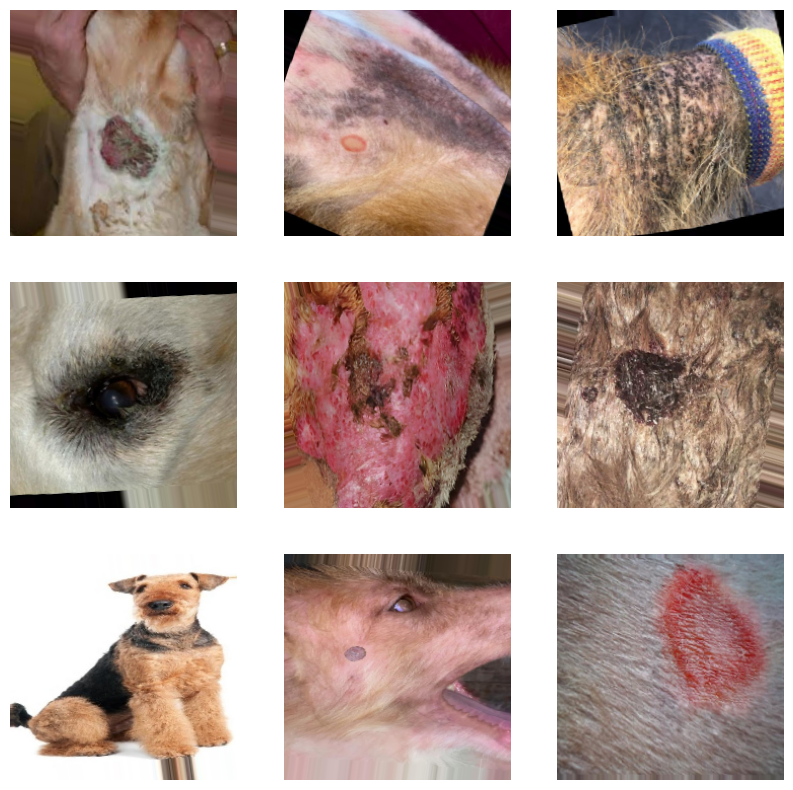

In [7]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()

In [8]:
cnn_model = Sequential([

    Conv2D(32,(3,3),activation='relu',
           input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(6,activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-05 14:16:04.010904: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = cnn_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.3084 - loss: 1.7497 - val_accuracy: 0.3826 - val_loss: 1.5797
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.4050 - loss: 1.4801 - val_accuracy: 0.4942 - val_loss: 1.3307
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.4653 - loss: 1.3729 - val_accuracy: 0.5081 - val_loss: 1.2576
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.4964 - loss: 1.2877 - val_accuracy: 0.5558 - val_loss: 1.1710
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.5321 - loss: 1.2281 - val_accuracy: 0.5802 - val_loss: 1.1181
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.5652 - loss: 1.1461 - val_accuracy: 0.5395 - val_loss: 1.1804
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.5966 - loss: 1.0849 - val_accuracy: 0.6279 - val_loss: 0.9921
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.6231 - loss: 1.0186 - val_accuracy: 0.6558 - v

In [10]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/josephsudheer0506
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Healthy
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Hypersensitivity
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Fungal_infections
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/ringworm
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Healthy
/kaggle/input/datasets/josephsudhe

In [11]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


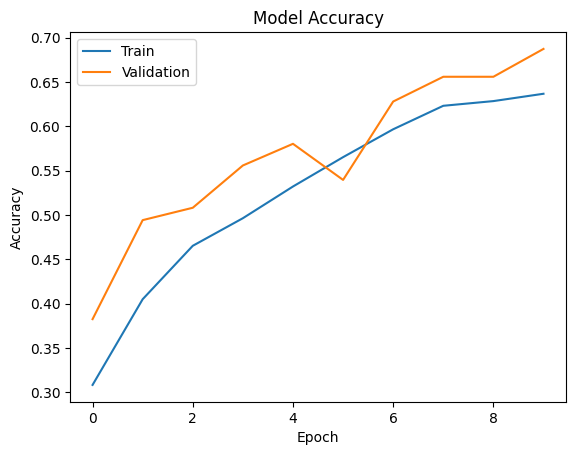

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.savefig('accuracy_curve.png')
plt.show()

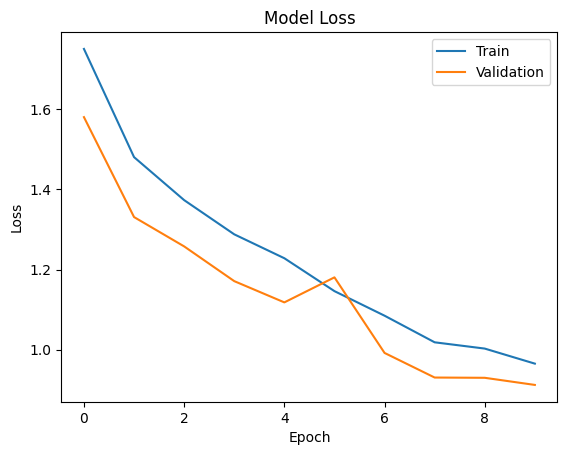

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.savefig('loss_curve.png')
plt.show()

In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(6, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input,
                        outputs=predictions)

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 2,388,614 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [16]:
history_mobilenet = mobilenet_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 320s 3s/step - accuracy: 0.7230 - loss: 0.7856 - val_accuracy: 0.2953 - val_loss: 13.1696
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 291s 3s/step - accuracy: 0.7968 - loss: 0.5869 - val_accuracy: 0.2488 - val_loss: 27.3431
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 299s 3s/step - accuracy: 0.8263 - loss: 0.4932 - val_accuracy: 0.2919 - val_loss: 14.0772
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 285s 3s/step - accuracy: 0.8557 - loss: 0.4151 - val_accuracy: 0.2628 - val_loss: 16.9608
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 289s 3s/step - accuracy: 0.8832 - loss: 0.3484 - val_accuracy: 0.2477 - val_loss: 24.1562
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 276s 3s/step - accuracy: 0.8858 - loss: 0.3506 - val_accuracy: 0.2465 - val_loss: 19.4509
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 274s 3s/step - accuracy: 0.9001 - loss: 0.2886 - val_accuracy: 0.2837 - val_loss: 13.3505
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 276s 3s/step - accuracy: 0.8994 - loss: 0.3027 - val_accuracy: 0.2

In [17]:
import numpy as np

predictions = cnn_model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 328ms/step


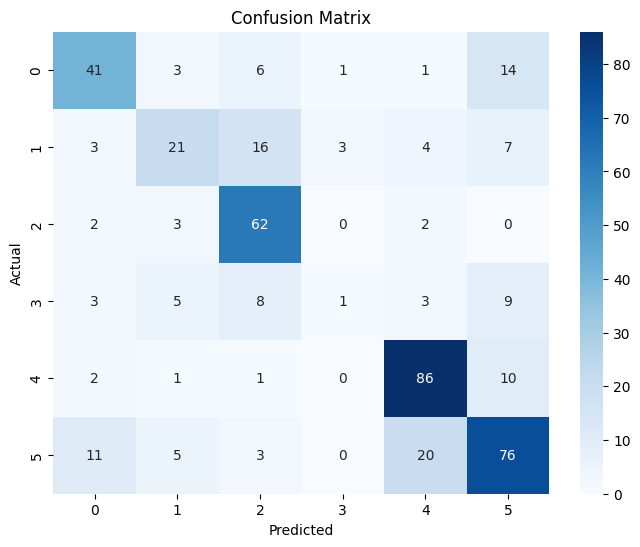

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")
plt.show()

In [19]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_data.classes,
        y_pred,
        target_names=list(test_data.class_indices.keys())
    )
)

                   precision    recall  f1-score   support

       Dermatitis       0.66      0.62      0.64        66
Fungal_infections       0.55      0.39      0.46        54
          Healthy       0.65      0.90      0.75        69
 Hypersensitivity       0.20      0.03      0.06        29
      demodicosis       0.74      0.86      0.80       100
         ringworm       0.66      0.66      0.66       115

         accuracy                           0.66       433
        macro avg       0.58      0.58      0.56       433
     weighted avg       0.63      0.66      0.64       433



In [20]:
cnn_model.save("livestock_skin_disease_model.h5")

In [34]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(6, activation='softmax')(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_data)

print("MobileNetV2 Test Accuracy:", test_accuracy)
print("MobileNetV2 Test Loss:", test_loss)

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 485ms/step - accuracy: 0.7621 - loss: 0.6238
MobileNetV2 Test Accuracy: 0.7621247172355652
MobileNetV2 Test Loss: 0.6238327622413635


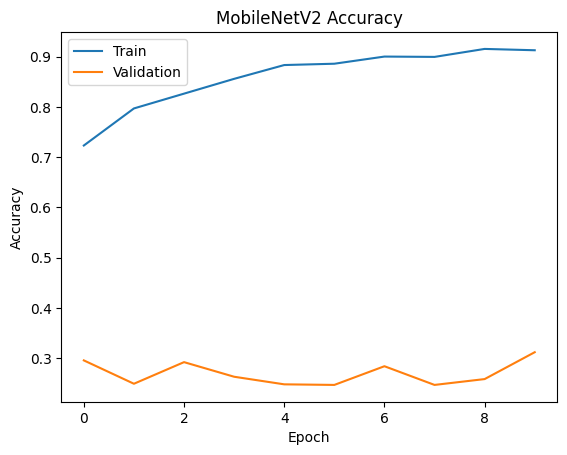

In [27]:
import matplotlib.pyplot as plt

plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.savefig('mobilenet_accuracy.png')
plt.show()

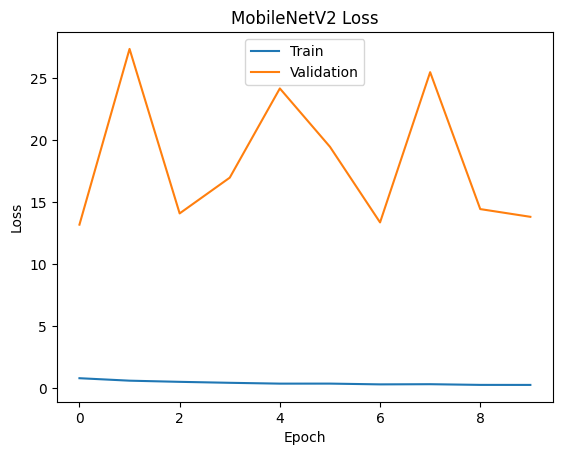

In [28]:
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])
plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.savefig('mobilenet_loss.png')
plt.show()

In [29]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_data)

print("MobileNetV2 Test Accuracy:", test_accuracy)
print("MobileNetV2 Test Loss:", test_loss)

14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 475ms/step - accuracy: 0.7621 - loss: 0.6238
MobileNetV2 Test Accuracy: 0.7621247172355652
MobileNetV2 Test Loss: 0.6238327622413635


In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

predictions = mobilenet_model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(
    test_data.classes,
    y_pred,
    target_names=list(test_data.class_indices.keys())
))

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 535ms/step
                   precision    recall  f1-score   support

       Dermatitis       0.77      0.76      0.76        66
Fungal_infections       0.55      0.54      0.54        54
          Healthy       0.83      0.84      0.83        69
 Hypersensitivity       0.67      0.07      0.12        29
      demodicosis       0.78      0.94      0.85       100
         ringworm       0.80      0.84      0.82       115

         accuracy                           0.76       433
        macro avg       0.73      0.66      0.66       433
     weighted avg       0.75      0.76      0.74       433



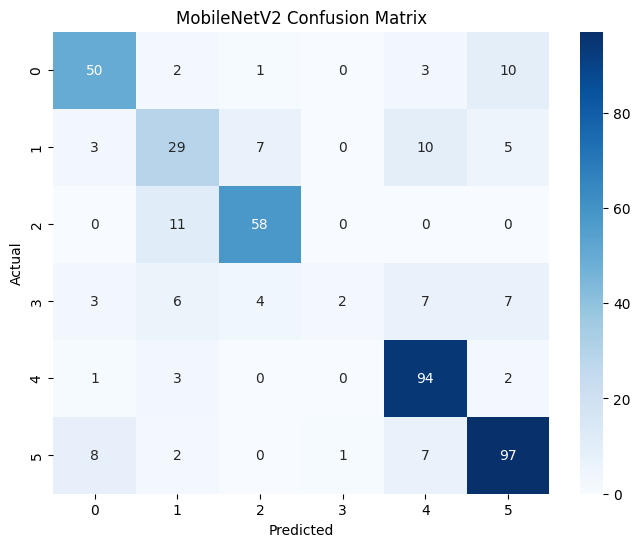

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("mobilenet_confusion_matrix.png")
plt.show()